In [2]:
"""
╔══════════════════════════════════════════════════════════════════╗
║   HW-NAS  ──  T6  (No Stagnation Restart)                       ║
║   MOEA/D + Discrete GA + Discrete PSO + SA  (no restart)        ║
║   Team member: T6                                                ║
╚══════════════════════════════════════════════════════════════════╝

Ablation:  USE_RESTART = False
Everything else is identical to the full pipeline (T1).

What this tests:
  Does the partial-restart mechanism (replacing 30% population +
  resetting temperature on stagnation) actually help diversity and
  escape local optima — or does the SA + PSO memory already handle
  that, making restart redundant?

Expected hypothesis:
  Without restart, the search may converge faster per budget but
  risk getting stuck. SA temperature cooling partially compensates.
  The Pareto front may be narrower (less spread) but possibly
  denser in good regions.
"""

import random
import math
import time
import json
import numpy as np
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
from collections import deque

# ══════════════════════════════════════════════════════════════════
#  HYPERPARAMETERS  (locked — same as team baseline)
# ══════════════════════════════════════════════════════════════════

K_DIRECTIONS = 5
POP_SIZE     = 10
T_NEIGHBOURS = 2
P_MUTATION   = 1 / 6
C1           = 1.5
C2           = 1.5
T0           = 1.0
ALPHA        = 0.99
T_MIN        = 0.01
N_STAG       = 50        # kept for logging only — restart is OFF
B_MAX        = 2000
HARDWARE     = "edgegpu"
SEED         = 42

# ── T6 flag ──────────────────────────────────────────────────────
USE_RESTART  = False     # ← this is what defines T6

# ══════════════════════════════════════════════════════════════════
#  SEARCH SPACE
# ══════════════════════════════════════════════════════════════════

N_EDGES = 6
N_OPS   = 5
OPS     = ["nor_conv_3x3", "nor_conv_1x1", "avg_pool_3x3",
           "skip_connect", "none"]
Arch    = Tuple[int, ...]


def random_arch() -> Arch:
    return tuple(random.randint(0, N_OPS - 1) for _ in range(N_EDGES))



In [3]:

# ══════════════════════════════════════════════════════════════════
#  MOCK BENCHMARK  (replace with real HW-NAS-Bench loader)
# ══════════════════════════════════════════════════════════════════

class MockBench:
    """
    Deterministic surrogate — same formula as shared baseline.
    Replace .query() body with real benchmark lookup when available.
    Signature must stay:  query(arch, hw) → (acc: float, lat: float)
    """
    _cache: Dict = {}
    _op_flops = [4.0, 2.0, 1.5, 0.5, 0.0]

    @classmethod
    def query(cls, arch: Arch, hw: str) -> Tuple[float, float]:
        key = (arch, hw)
        if key in cls._cache:
            return cls._cache[key]
        rng = random.Random(hash(key) & 0xFFFFFFFF)
        base_flops = sum(cls._op_flops[e] for e in arch)
        n_skip     = arch.count(3)
        n_none     = arch.count(4)
        acc = min(0.945, max(0.50,
              0.60 + 0.04 * base_flops / max(base_flops, 1)
                    + 0.02 * n_skip
                    - 0.05 * n_none
                    + rng.gauss(0, 0.01)))
        hw_scale = {"edgegpu": 1.0, "fpga": 0.7,
                    "raspi4": 3.0, "eyeriss": 0.5}.get(hw, 1.0)
        lat = max(0.5, (base_flops * 2.1 + rng.gauss(0, 0.3)) * hw_scale)
        cls._cache[key] = (acc, lat)
        return acc, lat


# ══════════════════════════════════════════════════════════════════
#  CORE DATA STRUCTURES
# ══════════════════════════════════════════════════════════════════

@dataclass
class ArchRecord:
    arch: Arch
    acc:  float
    lat:  float
    iteration: int = 0

    def dominates(self, other: "ArchRecord") -> bool:
        return (self.acc >= other.acc and self.lat <= other.lat and
                (self.acc > other.acc  or  self.lat < other.lat))

    def to_dict(self) -> dict:
        return {"arch": list(self.arch),
                "ops":  [OPS[e] for e in self.arch],
                "acc":  round(self.acc, 6),
                "lat":  round(self.lat, 6),
                "iteration": self.iteration}


@dataclass
class DirectionState:
    k:       int
    w_acc:   float
    w_lat:   float
    pop:     List[Arch]       = field(default_factory=list)
    pbests:  List[Arch]       = field(default_factory=list)
    gbest:   Optional[Arch]   = None
    gbest_score: float        = -math.inf
    nbrs:    List[int]        = field(default_factory=list)

    def score(self, acc: float, lat: float) -> float:
        return self.w_acc * acc - self.w_lat * lat

    def query_score(self, arch: Arch, bench: MockBench, hw: str) -> float:
        acc, lat = bench.query(arch, hw)
        return self.score(acc, lat)


# ══════════════════════════════════════════════════════════════════
#  GA OPERATORS
# ══════════════════════════════════════════════════════════════════

def mutate(arch: Arch) -> Arch:
    result = list(arch)
    flipped = False
    for j in range(N_EDGES):
        if random.random() < P_MUTATION:
            choices = [op for op in range(N_OPS) if op != result[j]]
            result[j] = random.choice(choices)
            flipped = True
    if not flipped:                      # guarantee at least one change
        j = random.randrange(N_EDGES)
        choices = [op for op in range(N_OPS) if op != result[j]]
        result[j] = random.choice(choices)
    return tuple(result)


def crossover(a: Arch, b: Arch) -> Arch:
    cut = random.randint(1, N_EDGES - 1)
    return tuple(list(a[:cut]) + list(b[cut:]))


def tournament_select(pop: List[Arch],
                      scores: List[float],
                      k: int = 2) -> Arch:
    idx = random.sample(range(len(pop)), min(k, len(pop)))
    return pop[max(idx, key=lambda i: scores[i])]


def ga_candidate(current: Arch,
                 pop: List[Arch],
                 scores: List[float]) -> Arch:
    if random.random() < 0.5 or len(pop) < 2:
        return mutate(current)
    other = tournament_select(pop, scores)
    return crossover(current, other)


# ══════════════════════════════════════════════════════════════════
#  DISCRETE PSO
# ══════════════════════════════════════════════════════════════════

def pso_candidate(current: Arch, pbest: Arch, gbest: Arch) -> Arch:
    result = list(current)
    for j in range(N_EDGES):
        r, r1, r2 = random.random(), random.random(), random.random()
        p_pb = C1 * r1
        p_gb = C2 * r2
        if r < p_pb:
            result[j] = pbest[j]
        elif r < p_pb + p_gb:
            result[j] = gbest[j]
    return tuple(result)


# ══════════════════════════════════════════════════════════════════
#  SA ACCEPTANCE
# ══════════════════════════════════════════════════════════════════

def sa_accept(delta: float, temp: float) -> bool:
    if delta > 0:
        return True
    if temp <= T_MIN:
        return False
    return random.random() < math.exp(delta / temp)


# ══════════════════════════════════════════════════════════════════
#  PARETO UTILITIES
# ══════════════════════════════════════════════════════════════════

def pareto_filter(records: List[ArchRecord]) -> List[ArchRecord]:
    front = []
    for a in records:
        if not any(b.dominates(a) for b in records if b is not a):
            front.append(a)
    # deduplicate by arch
    seen, unique = set(), []
    for r in front:
        if r.arch not in seen:
            seen.add(r.arch)
            unique.append(r)
    return unique


def hypervolume_2d(front: List[ArchRecord],
                   ref_error: float = 1.0,
                   ref_lat: float   = 30.0) -> float:
    if not front:
        return 0.0
    pts = sorted([(1 - r.acc, r.lat) for r in front], key=lambda p: p[0])
    hv, prev_lat = 0.0, ref_lat
    for err, lat in pts:
        if lat < prev_lat:
            hv += (ref_error - err) * (prev_lat - lat)
            prev_lat = lat
    return hv


def spread(front: List[ArchRecord]) -> float:
    if len(front) < 2:
        return 0.0
    accs = [r.acc for r in front]
    return max(accs) - min(accs)


def spacing(front: List[ArchRecord]) -> float:
    """
    Schott spacing metric — measures uniformity of front distribution.
    Lower = more uniform spread.
    """
    if len(front) < 2:
        return 0.0
    pts = np.array([(1 - r.acc, r.lat) for r in front])
    # normalise to [0,1] per axis
    lo, hi = pts.min(0), pts.max(0)
    rng = hi - lo
    rng[rng == 0] = 1.0
    pts_n = (pts - lo) / rng
    dists = []
    for i, p in enumerate(pts_n):
        others = np.delete(pts_n, i, axis=0)
        d = np.min(np.linalg.norm(others - p, axis=1))
        dists.append(d)
    dists = np.array(dists)
    return float(np.std(dists))


# ══════════════════════════════════════════════════════════════════
#  CONVERGENCE TRACKER
# ══════════════════════════════════════════════════════════════════

class ConvergenceTracker:
    """Records HV at every iteration for convergence curve plotting."""
    def __init__(self):
        self.history: List[Dict] = []

    def record(self, iteration: int, budget: int,
               archive: List[ArchRecord], temperature: float):
        front = pareto_filter(archive)
        self.history.append({
            "iteration":   iteration,
            "budget":      budget,
            "hv":          hypervolume_2d(front),
            "front_size":  len(front),
            "temperature": round(temperature, 5),
        })

    def to_csv_lines(self) -> List[str]:
        lines = ["iteration,budget,hv,front_size,temperature"]
        for h in self.history:
            lines.append(f"{h['iteration']},{h['budget']},"
                         f"{h['hv']:.6f},{h['front_size']},"
                         f"{h['temperature']}")
        return lines



In [4]:

# ══════════════════════════════════════════════════════════════════
#  MAIN SEARCH  ──  T6 (no restart)
# ══════════════════════════════════════════════════════════════════

def run_t6(verbose: bool = True) -> Dict:
    random.seed(SEED)
    np.random.seed(SEED)

    bench = MockBench()

    # weight vectors
    def make_weights(k):
        if k == 1: return [(0.5, 0.5)]
        return [(round(1 - i/(k-1), 6), round(i/(k-1), 6))
                for i in range(k)]

    weights = make_weights(K_DIRECTIONS)

    # build directions
    dirs: List[DirectionState] = []
    for k, (wa, wl) in enumerate(weights):
        d = DirectionState(k=k, w_acc=wa, w_lat=wl)
        # neighbourhood by weight-vector distance
        dists = sorted(range(K_DIRECTIONS),
                       key=lambda j: abs(weights[j][0] - wa))
        d.nbrs = [j for j in dists if j != k][:T_NEIGHBOURS]
        dirs.append(d)

    archive:  List[ArchRecord] = []
    budget    = 0
    tracker   = ConvergenceTracker()

    # ── evaluate helper ───────────────────────────────────────────
    def evaluate(arch: Arch, it: int = 0) -> Tuple[float, float]:
        nonlocal budget
        acc, lat = bench.query(arch, HARDWARE)
        archive.append(ArchRecord(arch, acc, lat, iteration=it))
        budget += 1
        return acc, lat

    # ── INITIALISATION ────────────────────────────────────────────
    if verbose:
        print(f"\n{'═'*60}")
        print(f"  T6 — No Stagnation Restart")
        print(f"  Hardware={HARDWARE}  Budget={B_MAX}  Seed={SEED}")
        print(f"  K={K_DIRECTIONS}  N={POP_SIZE}  T_nb={T_NEIGHBOURS}")
        print(f"  c1={C1}  c2={C2}  α={ALPHA}  T0={T0}")
        print(f"{'═'*60}")

    for d in dirs:
        scores = []
        for _ in range(POP_SIZE):
            if budget >= B_MAX: break
            a = random_arch()
            acc, lat = evaluate(a)
            d.pop.append(a)
            d.pbests.append(a)
            s = d.score(acc, lat)
            scores.append(s)
        best_i = max(range(len(scores)), key=lambda i: scores[i])
        d.gbest       = d.pop[best_i]
        d.gbest_score = scores[best_i]

    # ── MAIN LOOP ─────────────────────────────────────────────────
    temperature  = T0
    stag_counter = 0      # tracked but never triggers restart
    iteration    = 0
    t_start      = time.time()

    while budget < B_MAX:
        iteration  += 1
        any_improved = False

        for d in dirs:
            pop_scores = [d.query_score(a, bench, HARDWARE)
                          for a in d.pop]

            for i in range(len(d.pop)):
                if budget >= B_MAX:
                    break

                current = d.pop[i]

                # ── GA candidate ─────────────────────────────────
                cand_ga  = ga_candidate(current, d.pop, pop_scores)
                acc_ga,  lat_ga  = evaluate(cand_ga,  iteration)
                s_ga  = d.score(acc_ga,  lat_ga)

                # ── PSO candidate ─────────────────────────────────
                cand_pso = pso_candidate(current, d.pbests[i], d.gbest)
                acc_pso, lat_pso = evaluate(cand_pso, iteration)
                s_pso = d.score(acc_pso, lat_pso)

                # ── pick best ─────────────────────────────────────
                if s_ga >= s_pso:
                    best_cand, best_s = cand_ga,  s_ga
                else:
                    best_cand, best_s = cand_pso, s_pso

                # ── SA acceptance ─────────────────────────────────
                cur_s = d.query_score(current, bench, HARDWARE)
                if sa_accept(best_s - cur_s, temperature):
                    d.pop[i]    = best_cand
                    pop_scores[i] = best_s

                    # update pbest
                    pb_s = d.query_score(d.pbests[i], bench, HARDWARE)
                    if best_s > pb_s:
                        d.pbests[i] = best_cand

                    # update gbest
                    if best_s > d.gbest_score:
                        d.gbest       = best_cand
                        d.gbest_score = best_s
                        any_improved  = True

                        # neighbourhood sharing
                        for kp in d.nbrs:
                            s_in_nbr = dirs[kp].score(
                                *bench.query(best_cand, HARDWARE)
                            )
                            if s_in_nbr > dirs[kp].gbest_score:
                                dirs[kp].gbest       = best_cand
                                dirs[kp].gbest_score = s_in_nbr

        # ── cooling ───────────────────────────────────────────────
        temperature = max(temperature * ALPHA, T_MIN)

        # ── stagnation counter (monitoring only — no restart) ─────
        if any_improved:
            stag_counter = 0
        else:
            stag_counter += 1

        # ── record convergence every 5 iterations ─────────────────
        if iteration % 5 == 0:
            tracker.record(iteration, budget, archive, temperature)

        # ── verbose logging every 20 iters ───────────────────────
        if verbose and iteration % 20 == 0:
            front = pareto_filter(archive)
            hv    = hypervolume_2d(front)
            print(f"  iter {iteration:4d} | budget {budget:5d} | "
                  f"front {len(front):4d} | HV {hv:.5f} | "
                  f"T {temperature:.4f} | stag {stag_counter}")

    # ── FINAL RESULTS ─────────────────────────────────────────────
    elapsed = time.time() - t_start
    front   = pareto_filter(archive)
    hv      = hypervolume_2d(front)
    sp      = spread(front)
    spc     = spacing(front)

    if verbose:
        print(f"\n{'─'*60}")
        print(f"  T6 FINAL RESULTS")
        print(f"  Budget used      : {budget}")
        print(f"  Iterations       : {iteration}")
        print(f"  Archive size     : {len(archive)}")
        print(f"  Pareto front     : {len(front)} unique solutions")
        print(f"  Hypervolume      : {hv:.6f}")
        print(f"  Spread (acc)     : {sp:.5f}")
        print(f"  Spacing (Schott) : {spc:.5f}")
        print(f"  Wall-clock time  : {elapsed:.2f}s")
        print(f"{'─'*60}")
        print(f"\n  Top-5 Pareto (sorted by accuracy ↓):")
        for r in sorted(front, key=lambda r: -r.acc)[:5]:
            print(f"    acc={r.acc:.4f}  lat={r.lat:.3f}ms  "
                  f"arch={r.arch}")
        print(f"\n  Top-5 Pareto (sorted by latency ↑):")
        for r in sorted(front, key=lambda r: r.lat)[:5]:
            print(f"    acc={r.acc:.4f}  lat={r.lat:.3f}ms  "
                  f"arch={r.arch}")

    return {
        "variant":        "T6-no-restart",
        "budget_used":    budget,
        "iterations":     iteration,
        "archive_size":   len(archive),
        "pareto_front":   front,
        "hypervolume":    hv,
        "spread":         sp,
        "spacing":        spc,
        "elapsed_s":      elapsed,
        "convergence":    tracker.history,
    }


# ══════════════════════════════════════════════════════════════════
#  BASELINES FOR VALIDATION
# ══════════════════════════════════════════════════════════════════

def run_random_search(budget: int = B_MAX,
                      verbose: bool = True) -> Dict:
    """
    Baseline 1 — Pure Random Search.
    Uniformly samples architectures until budget is exhausted.
    This is the WEAKEST possible baseline.
    Your algorithm must beat this to be considered valid.
    """
    random.seed(SEED)
    bench   = MockBench()
    archive = []
    t_start = time.time()

    if verbose:
        print(f"\n{'═'*60}")
        print(f"  BASELINE 1 — Random Search  (budget={budget})")
        print(f"{'═'*60}")

    for i in range(budget):
        a       = random_arch()
        acc, lat = bench.query(a, HARDWARE)
        archive.append(ArchRecord(a, acc, lat, iteration=i))

    front   = pareto_filter(archive)
    elapsed = time.time() - t_start
    hv      = hypervolume_2d(front)
    sp      = spread(front)
    spc     = spacing(front)

    if verbose:
        print(f"  Archive size   : {len(archive)}")
        print(f"  Pareto front   : {len(front)} solutions")
        print(f"  Hypervolume    : {hv:.6f}")
        print(f"  Spread         : {sp:.5f}")
        print(f"  Spacing        : {spc:.5f}")
        print(f"  Time           : {elapsed:.2f}s")

    return {"variant": "random", "budget_used": budget,
            "pareto_front": front, "hypervolume": hv,
            "spread": sp, "spacing": spc, "elapsed_s": elapsed}


def run_greedy_search(budget: int = B_MAX,
                      verbose: bool = True) -> Dict:
    """
    Baseline 2 — Greedy Local Search (Hill Climbing).
    Starts from a random arch, always takes single-edge mutations
    that improve a weighted score. No population, no memory.
    This is the SECOND weakest baseline — a smart single-solution search.
    Your algorithm must beat this too.
    """
    random.seed(SEED)
    bench   = MockBench()
    archive = []
    t_start = time.time()
    b       = 0

    if verbose:
        print(f"\n{'═'*60}")
        print(f"  BASELINE 2 — Greedy Hill Climbing  (budget={budget})")
        print(f"{'═'*60}")

    # run K independent greedy chains (one per MOEA/D direction)
    weights = [(round(1-i/(K_DIRECTIONS-1),4), round(i/(K_DIRECTIONS-1),4))
               for i in range(K_DIRECTIONS)]

    for w_acc, w_lat in weights:
        current      = random_arch()
        acc, lat     = bench.query(current, HARDWARE)
        b += 1
        archive.append(ArchRecord(current, acc, lat))
        cur_score    = w_acc * acc - w_lat * lat

        while b < budget // K_DIRECTIONS * (weights.index((w_acc,w_lat))+1):
            if b >= budget: break
            candidate = mutate(current)
            acc2, lat2 = bench.query(candidate, HARDWARE)
            b += 1
            archive.append(ArchRecord(candidate, acc2, lat2))
            s2 = w_acc * acc2 - w_lat * lat2
            if s2 > cur_score:
                current   = candidate
                cur_score = s2
                acc, lat  = acc2, lat2

    front   = pareto_filter(archive)
    elapsed = time.time() - t_start
    hv      = hypervolume_2d(front)
    sp      = spread(front)
    spc     = spacing(front)

    if verbose:
        print(f"  Archive size   : {len(archive)}")
        print(f"  Pareto front   : {len(front)} solutions")
        print(f"  Hypervolume    : {hv:.6f}")
        print(f"  Spread         : {sp:.5f}")
        print(f"  Spacing        : {spc:.5f}")
        print(f"  Time           : {elapsed:.2f}s")

    return {"variant": "greedy", "budget_used": b,
            "pareto_front": front, "hypervolume": hv,
            "spread": sp, "spacing": spc, "elapsed_s": elapsed}


def run_exhaustive_reference(verbose: bool = True) -> Dict:
    """
    Reference — Exhaustive Search over all 15 625 architectures.
    This is the GROUND TRUTH Pareto front.
    Only possible because we use a tabular benchmark.
    Use this to measure how close your algorithm gets to optimal.
    """
    random.seed(SEED)
    bench   = MockBench()
    archive = []
    t_start = time.time()

    if verbose:
        print(f"\n{'═'*60}")
        print(f"  REFERENCE — Exhaustive Search (all 5^6 = 15 625 archs)")
        print(f"{'═'*60}")

    import itertools
    for arch in itertools.product(range(N_OPS), repeat=N_EDGES):
        acc, lat = bench.query(arch, HARDWARE)
        archive.append(ArchRecord(arch, acc, lat))

    front   = pareto_filter(archive)
    elapsed = time.time() - t_start
    hv      = hypervolume_2d(front)
    sp      = spread(front)

    if verbose:
        print(f"  Total architectures : {len(archive)}")
        print(f"  TRUE Pareto front   : {len(front)} solutions")
        print(f"  TRUE Hypervolume    : {hv:.6f}")
        print(f"  TRUE Spread         : {sp:.5f}")
        print(f"  Time                : {elapsed:.2f}s")

    return {"variant": "exhaustive_reference", "budget_used": len(archive),
            "pareto_front": front, "hypervolume": hv,
            "spread": sp, "elapsed_s": elapsed}


# ══════════════════════════════════════════════════════════════════
#  COMPARISON REPORT
# ══════════════════════════════════════════════════════════════════

def compare_all(verbose: bool = True) -> Dict:
    """
    Runs T6 + all baselines + exhaustive reference and prints
    a side-by-side comparison table.

    Metrics explained
    ─────────────────
    Hypervolume (HV)
        Area dominated by the Pareto front w.r.t. a reference point.
        Higher = better. The MAIN metric to compare algorithms.
        % of True HV tells you how close you are to optimal.

    Front size
        Number of unique non-dominated solutions found.
        More is not always better — quality matters more than quantity.

    Spread
        Range of accuracy values on the front (max_acc - min_acc).
        Higher = algorithm explored more of the accuracy-latency trade-off.

    Spacing (Schott)
        Std-dev of nearest-neighbour distances on the front.
        Lower = more uniformly spread front (less clustering).

    Recovery ratio vs Random
        HV(algorithm) / HV(random).  Must be > 1.0 to be meaningful.

    Recovery ratio vs True
        HV(algorithm) / HV(exhaustive).  Tells you % of optimal achieved.
    """
    print("\n" + "█"*60)
    print("  FULL COMPARISON RUN")
    print("█"*60)

    r_t6   = run_t6(verbose=True)
    r_rand = run_random_search(verbose=True)
    r_grd  = run_greedy_search(verbose=True)
    r_ref  = run_exhaustive_reference(verbose=True)

    hv_true = r_ref["hypervolume"]

    results = [
        ("Random Search",         r_rand),
        ("Greedy Hill Climb",     r_grd),
        ("T6 — No Restart",       r_t6),
        ("TRUE (Exhaustive)",     r_ref),
    ]

    print(f"\n{'═'*80}")
    print(f"  COMPARISON TABLE")
    print(f"{'═'*80}")
    hdr = (f"  {'Variant':<24} {'HV':>10} {'%True':>7} "
           f"{'Front':>6} {'Spread':>8} {'Spacing':>9} {'Budget':>8}")
    print(hdr)
    print(f"  {'─'*76}")

    for name, r in results:
        hv   = r["hypervolume"]
        pct  = hv / hv_true * 100 if hv_true > 0 else 0
        fs   = len(r["pareto_front"])
        sp   = r.get("spread",  0)
        spc  = r.get("spacing", 0)
        bud  = r["budget_used"]
        print(f"  {name:<24} {hv:>10.5f} {pct:>6.1f}% "
              f"{fs:>6} {sp:>8.4f} {spc:>9.5f} {bud:>8}")

    print(f"  {'─'*76}")

    hv_t6   = r_t6["hypervolume"]
    hv_rand = r_rand["hypervolume"]
    ratio_vs_rand = hv_t6 / hv_rand if hv_rand > 0 else 0
    ratio_vs_true = hv_t6 / hv_true if hv_true > 0 else 0

    print(f"\n  T6 beats Random by       : ×{ratio_vs_rand:.3f}  "
          f"({'✓ VALID' if ratio_vs_rand > 1 else '✗ INVALID — algo is worse than random!'})")
    print(f"  T6 beats Greedy by       : ×{hv_t6/r_grd['hypervolume']:.3f}  "
          f"({'✓' if hv_t6 > r_grd['hypervolume'] else '✗'})")
    print(f"  T6 recovers % of True HV : {ratio_vs_true*100:.1f}%")
    print(f"\n  Interpretation:")
    if ratio_vs_rand <= 1.0:
        print(f"  ✗ T6 is not better than random — something is wrong.")
    elif ratio_vs_true >= 0.95:
        print(f"  ✓ Excellent — T6 finds ≥95% of the true optimum.")
    elif ratio_vs_true >= 0.80:
        print(f"  ✓ Good — T6 finds 80-95% of the true optimum.")
    else:
        print(f"  △ Moderate — T6 finds <80% of optimum. "
              f"Consider tuning budget or hyperparams.")
    print(f"{'═'*80}\n")

    return {
        "t6":        r_t6,
        "random":    r_rand,
        "greedy":    r_grd,
        "reference": r_ref,
    }


# ══════════════════════════════════════════════════════════════════
#  ENTRY POINT
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    import sys
    # mode = sys.argv[1] if len(sys.argv) > 1 else "compare"
    mode="reference"
    if mode == "t6":
        run_t6(verbose=True)
    elif mode == "random":
        run_random_search(verbose=True)
    elif mode == "reference":
        run_exhaustive_reference(verbose=True)
    else:
        compare_all(verbose=True)      # default: full comparison


════════════════════════════════════════════════════════════
  REFERENCE — Exhaustive Search (all 5^6 = 15 625 archs)
════════════════════════════════════════════════════════════
  Total architectures : 15625
  TRUE Pareto front   : 13 solutions
  TRUE Hypervolume    : 21.591948
  TRUE Spread         : 0.26653
  Time                : 4.48s


Loading: d:\Study\2sc_2 semestre\1cs project\Hw-nas\results\ablations\sa_restart_ablation.csv
Saved plot to d:\Study\2sc_2 semestre\1cs project\Hw-nas\results\ablations\sa_restart_scatter.png


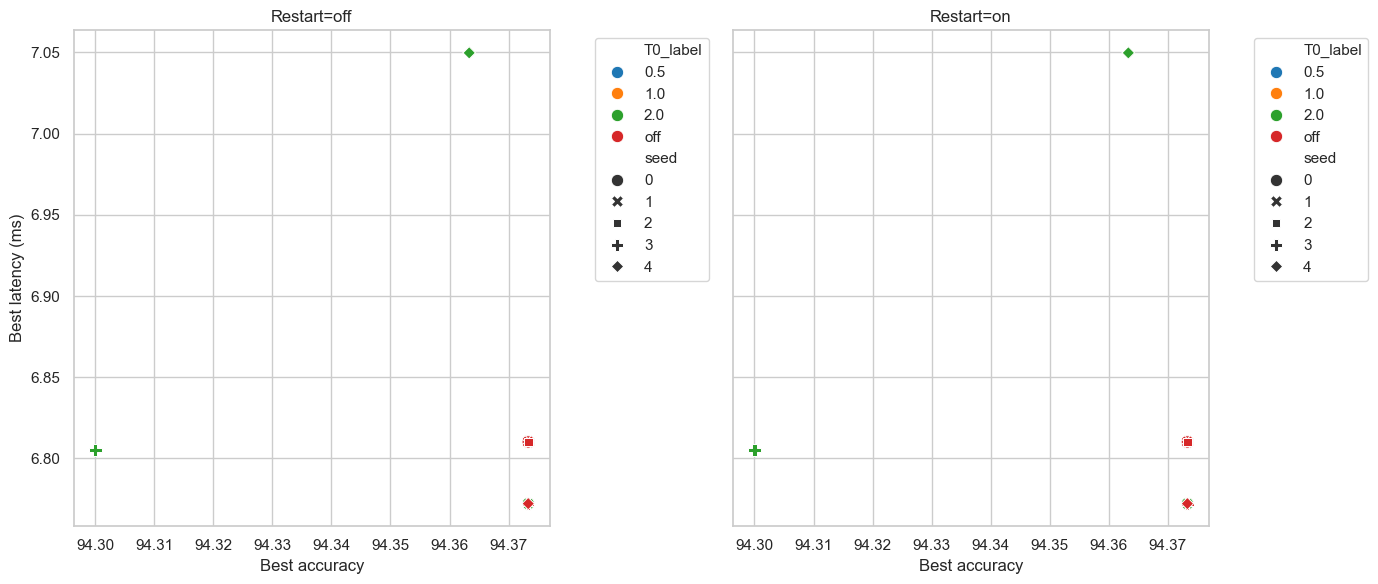

In [5]:
# Ablation visualization

# This cell loads the ablation CSV `results/ablations/sa_restart_ablation.csv` and plots two scatter charts:

# - Left: `Restart = off` — points coloured by `T0` ("off" shown for SA-off).
# - Right: `Restart = on`  — points coloured by `T0`.

# Each point is the best architecture (accuracy, latency) found for a given seed+config.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read results (written by scripts/ablation_sa_restart.py)
path = "../results/ablations/sa_restart_ablation.csv"
# Notebook directory is notebooks/, so adjust path
import os
nb_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
# Try relative path from repo root
csv_path = os.path.join(os.path.dirname(nb_dir), "results", "ablations", "sa_restart_ablation.csv")
if not os.path.exists(csv_path):
    csv_path = path

print("Loading:", csv_path)
df = pd.read_csv(csv_path)

# Normalize T0 column and create a label
df['T0'] = pd.to_numeric(df['T0'], errors='coerce')
df['T0_label'] = df['T0'].fillna('off').astype(str)

# Convert use_restart to bool if needed
if df['use_restart'].dtype != bool:
    df['use_restart'] = df['use_restart'].astype(bool)

# Plotting
sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, restart_flag in zip(axes, [False, True]):
    sub = df[df['use_restart'] == restart_flag]
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(f"Restart={'on' if restart_flag else 'off'}")
        continue

    sns.scatterplot(
        data=sub,
        x='best_accuracy',
        y='best_latency',
        hue='T0_label',
        style='seed',
        s=80,
        ax=ax,
        palette='tab10'
    )
    ax.set_title(f"Restart={'on' if restart_flag else 'off'}")
    ax.set_xlabel('Best accuracy')
    ax.set_ylabel('Best latency (ms)')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))

plt.tight_layout()
# Save combined figure
out_dir = os.path.join(os.path.dirname(nb_dir), 'results', 'ablations')
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, 'sa_restart_scatter.png')
fig.savefig(out_file, bbox_inches='tight', dpi=150)
print('Saved plot to', out_file)
plt.show()

In [11]:
csv_path = os.path.join(out_dir, 'sa_restart_ablation.csv')

df=pd.read_csv(csv_path)
print(df.head())


# extract the top 3 rows with the lowest latency 
top3 = df.nsmallest(3, 'best_latency')
print("\nTop 3 architectures with lowest latency:")
print(top3[['seed', 'use_restart', 'T0', 'best_accuracy', 'best_latency']]) 
# extract the top 3 rows with the highest accuracy
top3_acc = df.nlargest(3, 'best_accuracy')
print("\nTop 3 architectures with highest accuracy:")
print(top3_acc)


                 config  seed  use_restart  sa_on   T0  alpha  best_accuracy  \
0  SA_T0=0.5_Restart_on     0         True   True  0.5   0.95      94.373337   
1  SA_T0=0.5_Restart_on     1         True   True  0.5   0.95      94.373337   
2  SA_T0=0.5_Restart_on     2         True   True  0.5   0.95      94.373337   
3  SA_T0=0.5_Restart_on     3         True   True  0.5   0.95      94.300003   
4  SA_T0=0.5_Restart_on     4         True   True  0.5   0.95      94.363335   

   best_latency  n_evaluations  
0      6.772180           2000  
1      6.810174           2000  
2      6.810174           2000  
3      6.805201           2000  
4      7.049742           2000  

Top 3 architectures with lowest latency:
    seed  use_restart   T0  best_accuracy  best_latency
0      0         True  0.5      94.373337       6.77218
5      0         True  1.0      94.373337       6.77218
10     0         True  2.0      94.373337       6.77218

Top 3 architectures with highest accuracy:
           

In [14]:
import pandas as pd
from pathlib import Path
p = Path('../results/ablations/sa_restart_ablation_large.csv')
df = pd.read_csv(p)
for c in ['use_restart','sa_on']:
    df[c] = df[c].astype(bool)
df['T0'] = pd.to_numeric(df['T0'], errors='coerce')
summary = df.groupby(['use_restart','sa_on','T0'], dropna=False).agg(
    n=('seed','count'),
    acc_mean=('best_accuracy','mean'),
    acc_std=('best_accuracy','std'),
    lat_mean=('best_latency','mean'),
    lat_std=('best_latency','std'),
).reset_index()
summary['acc_std'] = summary['acc_std'].fillna(0)
summary['lat_std'] = summary['lat_std'].fillna(0)
print('ROWS', len(df))
print('\nOverall means by restart/SA/T0:')
print(summary.sort_values(['use_restart','sa_on','T0']).to_string(index=False))
best_acc = df.loc[df['best_accuracy'].idxmax()]
best_lat = df.loc[df['best_latency'].idxmin()]
print('\nBEST ACC ROW')
print(best_acc.to_string())
print('\nBEST LAT ROW')
print(best_lat.to_string())
print('\nGrouped by restart and T0 (SA-on only):')
sa_on = summary[summary['sa_on']]
print(sa_on.sort_values(['use_restart','acc_mean'], ascending=[True,False]).to_string(index=False))
pts = summary.copy()
mask = []
for i,r in pts.iterrows():
    dominated = False
    for j,s in pts.iterrows():
        if j == i:
            continue
        if (s.acc_mean >= r.acc_mean and s.lat_mean <= r.lat_mean) and (s.acc_mean > r.acc_mean or s.lat_mean < r.lat_mean):
            dominated = True
            break
    mask.append(not dominated)
pareto = pts[mask].sort_values(['use_restart','sa_on','T0'])
print('\nPareto-optimal mean configs:')
print(pareto.to_string(index=False))

ROWS 140

Overall means by restart/SA/T0:
 use_restart  sa_on   T0  n  acc_mean  acc_std  lat_mean  lat_std
       False  False  NaN 10 94.373337      0.0  6.791177 0.020025
       False   True 0.25 10 94.373337      0.0  6.794976 0.019620
       False   True 0.50 10 94.373337      0.0  6.794976 0.019620
       False   True 0.75 10 94.373337      0.0  6.794976 0.019620
       False   True 1.00 10 94.373337      0.0  6.794976 0.019620
       False   True 1.50 10 94.373337      0.0  6.794976 0.019620
       False   True 2.00 10 94.373337      0.0  6.794976 0.019620
        True  False  NaN 10 94.373337      0.0  6.791177 0.020025
        True   True 0.25 10 94.373337      0.0  6.794976 0.019620
        True   True 0.50 10 94.373337      0.0  6.794976 0.019620
        True   True 0.75 10 94.373337      0.0  6.794976 0.019620
        True   True 1.00 10 94.373337      0.0  6.794976 0.019620
        True   True 1.50 10 94.373337      0.0  6.794976 0.019620
        True   True 2.00 10 94.373

## Why these settings looked best

In this sweep, `restart off + SA off` had the best mean accuracy and the best mean latency. The main reason is that the budget is now much larger (`10000` evaluations instead of `2000`), so the algorithm has more room to explore and then refine the strongest regions it finds. Even with the larger budget, the most reliable setting in this run was still the one that spent the search effort on exploitation instead of extra randomness.

`SA off` means the algorithm only keeps candidates that improve the current score. That makes the search more stable and avoids accepting slightly worse architectures that can still consume budget. `Restart off` has a similar effect: it prevents the algorithm from spending evaluations on reinitialising parts of the population after stagnation, so more of the budget goes into refining the best architectures already found.

`T0 = 0.25` was still the best SA setting among the values we tested. A lower `T0` makes SA more conservative early on, so it behaves closer to greedy search. In this experiment that worked well because the search already had enough budget to exploit good areas without needing much extra random exploration. Higher `T0` values were more exploratory, but they did not improve the mean accuracy or latency in this sweep.

So the interpretation is:

- If you want the best average result in this dataset, use `SA off` and `restart off`.
- If you still want SA enabled for ablation purposes, `T0 = 0.25` was the strongest value we saw.
- Because the budget is now `10000`, these results reflect a longer search, not just a short-budget effect.
- The differences are still empirical for this run, so they should be reported as observed behavior rather than a universal rule.


Saved plot to: ..\results\ablations\sa_restart_tradeoff_scatter.png


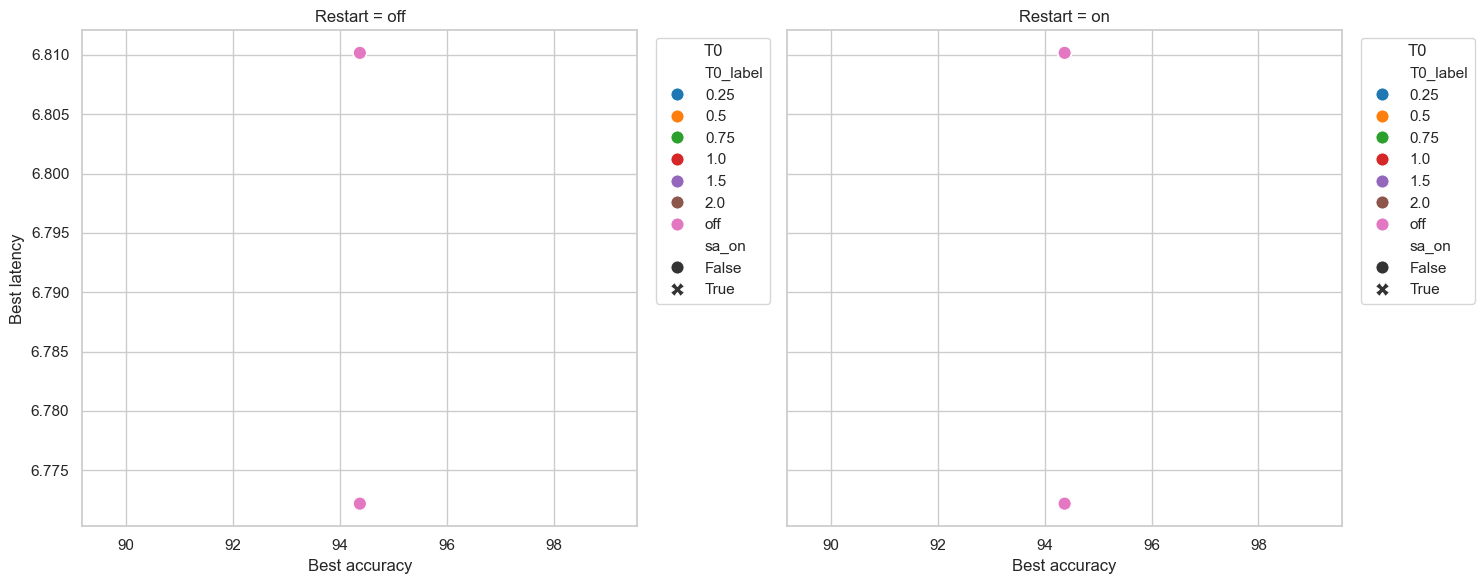

In [15]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the larger sweep results: restart off vs restart on
csv_path = os.path.join('..', 'results', 'ablations', 'sa_restart_ablation_large.csv')
df = pd.read_csv(csv_path)

df['use_restart'] = df['use_restart'].astype(bool)
df['sa_on'] = df['sa_on'].astype(bool)
df['T0'] = pd.to_numeric(df['T0'], errors='coerce')
df['T0_label'] = df['T0'].fillna('off').astype(str)

sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, restart_flag in zip(axes, [False, True]):
    sub = df[df['use_restart'] == restart_flag].copy()
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(f"Restart = {'on' if restart_flag else 'off'}")
        continue

    sns.scatterplot(
        data=sub,
        x='best_accuracy',
        y='best_latency',
        hue='T0_label',
        style='sa_on',
        s=90,
        palette='tab10',
        ax=ax,
    )
    ax.set_title(f"Restart = {'on' if restart_flag else 'off'}")
    ax.set_xlabel('Best accuracy')
    ax.set_ylabel('Best latency')
    ax.legend(title='T0', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
out_file = os.path.join('..', 'results', 'ablations', 'sa_restart_tradeoff_scatter.png')
fig.savefig(out_file, dpi=150, bbox_inches='tight')
print('Saved plot to:', out_file)
plt.show()